In [218]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp

# plt.rcParams.update(
# {"text.usetex": True, "font.family": "Helvetica", "font.size": 8}
# )

plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri"],
        "font.size": 10,
        "mathtext.fontset": "cm",
    }
)

gnuplot_barve = cm.gnuplot2_r(np.linspace(0.3, 1, 10))
gnuplot_custom = LinearSegmentedColormap.from_list("gnuplot_custom", gnuplot_barve)

brg_barve = cmaps.guppy(np.linspace(0, 1, 10))
bgr_custom = LinearSegmentedColormap.from_list("bgr_custom", brg_barve)

YlGn_barve = cm.YlGn(np.linspace(0, 0.8, 10))
ylgn_custom = LinearSegmentedColormap.from_list("ylgn_custom", YlGn_barve)

markers = ["o", "D", "^", "x", "v", "<", ">", "p", "*", "X"]

set1_list = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#f781bf",
    "#999999",
    "#a65628",
]
bold_list = [
    "#7f3c8d",
    "#11a579",
    "#3969ac",
    "#e73f74",
    "#f2b701",
    "#80ba5a",
    "#e68310",
    "#008695",
    "#cf1c90",
    "#f97b72",
    "#a5aa99",
]

OUT = "/home/kzeleznikar/IJS-F1/Koda/toymodels/plots/"

W = 5.0
from utils import newfig, fd

import utils as ut
import ei_open_loop as eol
import ei_unified as eu
import ei_jax as ej

In [219]:
nk = 20

bd = eu.tb_2d(
    nk=nk,
    gap=1.0,
    ta=1.0,
    tb=-0.3,
)

p = eu.MFPars(
    v=5.0,
    n=1.0,
    uh=None,
)

s0 = eu.solve_eq(
    bd,
    p,
    t=0.0,
    d=1.0,
    m=0.0,
    mix=(0.15, 0.15),
    tol=1.0e-10,
    nmax=20000,
    chk=20,
    prog=True,
)

mu0 = s0.mu
d0 = abs(s0.d)

tc = eu.critical_temperature(
    bd,
    p,
    tlo=1.0e-4,
    thi=2.0,
    tol=1.0e-7,
    nmax=100,
    prog=True,
)

print("Delta_0 =", d0)
print("T_c     =", tc)
print("mu0     =", mu0)

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

Delta_0 = 1.3438528051317822
T_c     = 0.6195541953906416
mu0     = 2.452325281248757


In [220]:
nt = 50

tn = np.linspace(0.03, 1.5, nt)
t1a = tn * tc
t2a = tn * tc

In [221]:
def rate_custom(ei, ej, de, t, mu):
    x = (de) / t
    return 1 / (x + 1)

In [222]:
mua = np.empty(nt)
sea = [None] * nt

de = s0.d
me = s0.m

wc = np.inf
# wc=5.0

da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
it = np.zeros((nt, nt), dtype=int)
ok = np.zeros((nt, nt), dtype=bool)

de = s0.d
me = s0.m

for j in tqdm(range(nt), desc="T2 rows"):
    t2 = t2a[j]

    se = eu.solve_eq(
        bd,
        p,
        t=t2,
        d=max(abs(de), 1.0e-6),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    de = se.d
    me = se.m

    n = se.n.copy()
    d = se.d
    m = se.m

    for i in tqdm(
        range(j, nt),
        desc="T1 cols",
        leave=False,
    ):
        t1 = t1a[i]

        kaa = 0.3
        kab = 0.6
        kbb = 0.3

        bs = (
            ej.gam_db(
                t1, kap=(kaa, kab, kbb), wc=wc, mu=0, name="bath 1", rate=ej.rate_db
            ),
            ej.gam_db(
                t2, kap=(kaa, kab, kbb), wc=wc, mu=0, name="bath 2", rate=ej.rate_db
            ),
        )

        so = ej.solve_open(
            bd,
            p,
            n,
            bs,
            d=d,
            m=m,
            dt=0.8,
            td=0.3,
            tm=0.3,
            tol=1.0e-4,
            nmax=20000,
            chk=20,
            prog=False,
        )

        ds = 1.0 * d0

        da[j, i] = abs(so.d)
        ma[j, i] = so.m
        er[j, i] = so.err
        it[j, i] = so.it
        ok[j, i] = so.ok

        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

        da[i, j] = da[j, i]
        ma[i, j] = ma[j, i]
        er[i, j] = er[j, i]
        it[i, j] = it[j, i]
        ok[i, j] = ok[j, i]

T2 rows: 100%|██████████| 50/50 [00:50<00:00,  1.00s/it]


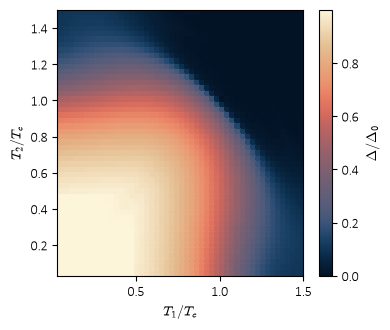

Converged: 2500 / 2500
Largest residual: 9.998201858252287e-05
Largest iteration count: 980


In [223]:
z = da / d0

h = 0.85
fig, ax = plt.subplots(figsize=(4, h * 4))

im = ax.pcolormesh(
    tn,
    tn,
    z,
    shading="auto",
    cmap=cmaps.lipari,
    vmin=0.0,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\Delta/\Delta_0$", rotation=90, labelpad=5)

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$T_2/T_c$")
ax.set_xlim(tn.min(), tn.max())
ax.set_ylim(tn.min(), tn.max())

plt.tight_layout()
# plt.savefig("EI_dbrate_gapcmap_jax.pdf")
plt.show()

print("Converged:", np.count_nonzero(ok), "/", ok.size)
print("Largest residual:", np.nanmax(er))
print("Largest iteration count:", np.max(it))

In [34]:
mua = np.empty(nt)
sea = []

de = s0.d
me = s0.m

for q in tqdm(range(nt), desc="Equilibrium references"):
    sq = eu.solve_eq(
        bd,
        p,
        t=t1a[q],
        d=max(abs(de), 1.0e-6),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    mua[q] = sq.mu
    sea.append(sq)

    de = sq.d
    me = sq.m

Equilibrium references: 100%|██████████| 50/50 [00:11<00:00,  4.27it/s]


In [35]:
print(mua)
mu_B = np.mean(mua[: -len(mua) // 2])

[-0.61746876  0.24998426  0.25        0.25        0.25        0.25
  0.25        0.25        0.25        0.25        0.25        0.25
  0.25        0.25        0.25        0.25        0.25        0.25
  0.25        0.25        0.25        0.25        0.25        0.25
  0.25        0.25        0.25        0.25        0.25        0.25
  0.25        0.25        0.25        0.25        0.25        0.25
  0.25        0.25        0.25        0.25        0.25        0.25
  0.25        0.25        0.25        0.25        0.25        0.25
  0.25        0.25      ]


In [38]:
de = s0.d
me = s0.m

wc = np.inf

da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
it = np.zeros((nt, nt), dtype=int)
ok = np.zeros((nt, nt), dtype=bool)

de = s0.d
me = s0.m

for j in tqdm(range(nt), desc="T2 rows"):
    t2 = t2a[j]

    se = eu.solve_eq(
        bd,
        p,
        t=t2,
        d=max(abs(de), 1.0e-6),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-6,
        nmax=20000,
        chk=20,
        prog=False,
    )

    de = se.d
    me = se.m

    n = se.n.copy()
    d = se.d
    m = se.m

    for i in tqdm(
        range(j, nt),
        desc="T1 cols",
        leave=False,
    ):
        t1 = t1a[i]

        kaa = 0.1
        kab = 0.2
        kbb = 0.1

        bs = (
            ej.gam_db(
                t1,
                kap=(kaa, kab, kbb),
                wc=wc,
                mu=mu_B,
                name="bath 1",
                rate=ej.rate_product,
            ),
            ej.gam_db(
                t2,
                kap=(kaa, kab, kbb),
                wc=wc,
                mu=mu_B,
                name="bath 2",
                rate=ej.rate_product,
            ),
        )

        so = ej.solve_open(
            bd,
            p,
            n,
            bs,
            d=d,
            m=m,
            dt=0.8,
            td=0.3,
            tm=0.3,
            tol=1.0e-4,
            nmax=20000,
            chk=20,
            prog=False,
            mode="pair",
        )

        ds = 1.0 * d0

        da[j, i] = abs(so.d)
        ma[j, i] = so.m
        er[j, i] = so.err
        it[j, i] = so.it
        ok[j, i] = so.ok

        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

        da[i, j] = da[j, i]
        ma[i, j] = ma[j, i]
        er[i, j] = er[j, i]
        it[i, j] = it[j, i]
        ok[i, j] = ok[j, i]

T2 rows: 100%|██████████| 50/50 [00:10<00:00,  4.91it/s]


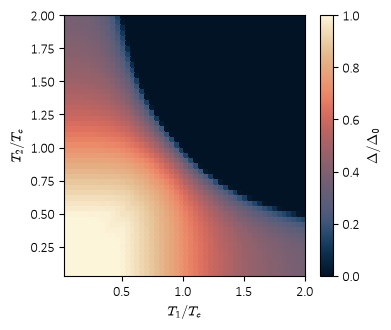

Converged: 2500 / 2500
Largest residual: 9.989738464355469e-05
Largest iteration count: 940


In [39]:
z = da / d0

h = 0.85
fig, ax = plt.subplots(figsize=(4, h * 4))

im = ax.pcolormesh(
    tn,
    tn,
    z,
    shading="auto",
    cmap=cmaps.lipari,
    vmin=0.0,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\Delta/\Delta_0$", rotation=90, labelpad=5)

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$T_2/T_c$")
ax.set_xlim(tn.min(), tn.max())
ax.set_ylim(tn.min(), tn.max())

plt.tight_layout()
# plt.savefig("EI_prodrate_gapcmap_jax.pdf")
plt.show()

print("Converged:", np.count_nonzero(ok), "/", ok.size)
print("Largest residual:", np.nanmax(er))
print("Largest iteration count:", np.max(it))

In [40]:
def make_rate_ph(s=3.0, e0=1.0, ep=1.0e-7):
    s = float(s)
    e0 = float(e0)
    ep = float(ep)

    def rate_ph(ei, ej, de, t, mu):
        w = jnp.abs(de)
        ws = jnp.maximum(w, ep)
        x = ws / t

        den = -jnp.expm1(-x)
        nb = jnp.exp(-x) / den

        bf = jnp.where(
            de > 0.0,
            nb,
            nb + 1.0,
        )

        js = (ws / e0) ** s
        return js * bf

    return rate_ph

In [ ]:
rate_ph = make_rate_ph(
    s=3.0,
    e0=1.0,
)

mua = np.empty(nt)
sea = [None] * nt

de = s0.d
me = s0.m

wc = np.inf

da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
it = np.zeros((nt, nt), dtype=int)
ok = np.zeros((nt, nt), dtype=bool)

de = s0.d
me = s0.m

for j in tqdm(range(nt), desc="T2 rows"):
    t2 = t2a[j]

    se = eu.solve_eq(
        bd,
        p,
        t=t2,
        d=max(abs(de), 1.0e-6),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    de = se.d
    me = se.m

    n = se.n.copy()
    d = se.d
    m = se.m

    for i in tqdm(
        range(j, nt),
        desc="T1 cols",
        leave=False,
    ):
        t1 = t1a[i]

        kaa = 0.1
        kab = 0.2
        kbb = 0.1

        bs = (
            ej.gam_db(
                t1, kap=(kaa, kab, kbb), wc=wc, mu=mu_B, name="bath 1", rate=rate_ph
            ),
            ej.gam_db(
                t2, kap=(kaa, kab, kbb), wc=wc, mu=mu_B, name="bath 2", rate=rate_ph
            ),
        )

        so = ej.solve_open(
            bd,
            p,
            n,
            bs,
            d=d,
            m=m,
            dt=0.8,
            td=0.3,
            tm=0.3,
            tol=1.0e-4,
            nmax=20000,
            chk=20,
            prog=False,
            mode="pair",
        )

        ds = 0.1 * d0

        da[j, i] = abs(so.d)
        ma[j, i] = so.m
        er[j, i] = so.err
        it[j, i] = so.it
        ok[j, i] = so.ok

        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

        da[i, j] = da[j, i]
        ma[i, j] = ma[j, i]
        er[i, j] = er[j, i]
        it[i, j] = it[j, i]
        ok[i, j] = ok[j, i]

T2 rows: 100%|██████████| 50/50 [07:01<00:00,  8.43s/it]


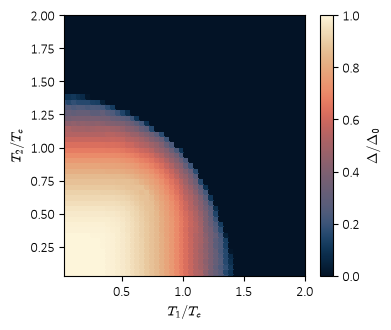

Converged: 317 / 2500
Largest residual: 193.825927734375
Largest iteration count: 20000


In [43]:
z = da / d0

h = 0.85
fig, ax = plt.subplots(figsize=(4, h * 4))

im = ax.pcolormesh(
    tn,
    tn,
    z,
    shading="auto",
    cmap=cmaps.lipari,
    vmin=0.0,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\Delta/\Delta_0$", rotation=90, labelpad=5)

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$T_2/T_c$")
ax.set_xlim(tn.min(), tn.max())
ax.set_ylim(tn.min(), tn.max())

plt.tight_layout()
# plt.savefig("EI_phrate_gapcmap_jax.pdf")
plt.show()

print("Converged:", np.count_nonzero(ok), "/", ok.size)
print("Largest residual:", np.nanmax(er))
print("Largest iteration count:", np.max(it))

1d sweep mu test za f(1-f)

In [44]:
nt1 = 100

t1n = np.linspace(1.10, 1.35, nt1)
t1a = t1n * tc

t2 = 0.05 * tc


dsx = 0.03 * d0
kaa = 0.05
kab = 0.6
kbb = 0.05

wc = np.inf
ds = 0.04 * d0

In [45]:
mua = np.empty(nt1)

de = s0.d
me = s0.m

for q in tqdm(
    range(nt1),
    desc="Equilibrium references",
):
    sq = eu.solve_eq(
        bd,
        p,
        t=t1a[q],
        d=max(abs(de), 1.0e-6),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    mua[q] = sq.mu

    de = sq.d
    me = sq.m

mu_m = np.mean(mua)

print("Minimum equilibrium mu:", mua.min())
print("Maximum equilibrium mu:", mua.max())
print("Mean equilibrium mu:", mu_m)

Equilibrium references: 100%|██████████| 100/100 [00:09<00:00, 10.18it/s]

Minimum equilibrium mu: 0.24999999999997458
Maximum equilibrium mu: 0.24999999999997458
Mean equilibrium mu: 0.24999999999997466


In [46]:
se2 = eu.solve_eq(
    bd,
    p,
    t=t2,
    d=max(abs(s0.d), ds),
    m=s0.m,
    mix=(0.15, 0.15),
    tol=1.0e-9,
    nmax=20000,
    chk=20,
    prog=True,
)

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

In [47]:
fa = np.linspace(0.95, 1.2, 10)

muba = fa * mu_m

In [48]:
dg = np.full(
    (fa.size, nt1),
    np.nan,
)

eg = np.full(
    (fa.size, nt1),
    np.nan,
)

og = np.zeros(
    (fa.size, nt1),
    dtype=bool,
)

for q in tqdm(
    range(fa.size),
    desc="Chemical potentials",
):
    mu_b = muba[q]

    n = se2.n.copy()
    d = max(abs(se2.d), ds)
    m = se2.m

    for i in tqdm(
        range(nt1),
        desc="T1 sweep",
        leave=False,
    ):
        t1 = t1a[i]

        bs = (
            ej.gam_db(
                t1,
                kap=(kaa, kab, kbb),
                wc=wc,
                mu=mu_b,
                name="bath 1",
            ),
            ej.gam_db(
                t2,
                kap=(kaa, kab, kbb),
                wc=wc,
                mu=mu_b,
                name="bath 2",
            ),
        )

        so = ej.solve_open(
            bd,
            p,
            n,
            bs,
            d=d,
            m=m,
            dt=0.4,
            td=0.5,
            tm=0.5,
            tol=1.0e-5,
            nmax=30000,
            chk=20,
            prog=False,
            mode="block",
            block=512,
        )

        dg[q, i] = abs(so.d) / d0
        eg[q, i] = so.err
        og[q, i] = so.ok

        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

Chemical potentials: 100%|██████████| 10/10 [00:02<00:00,  3.39it/s]


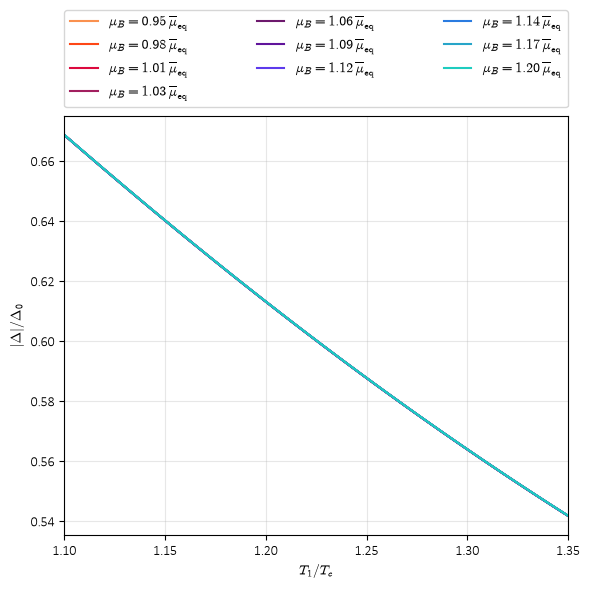

In [49]:
h = 1
fig, ax = plt.subplots(figsize=(6, h * 6))

for q in range(fa.size):
    y = np.where(
        og[q],
        dg[q],
        np.nan,
    )

    ax.plot(
        t1n,
        y,
        color=brg_barve[q],
        label=rf"$\mu_B={fa[q]:.2f}\,\overline{{\mu}}_{{\rm eq}}$",
    )

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$|\Delta|/\Delta_0$")

ax.set_xlim(t1n[0], t1n[-1])

ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=3,
)

plt.tight_layout()

In [50]:
xa = np.linspace(1.05, 1.15, 100)

t2 = 0.05 * tc
mu_b = 1.1 * mu_m

dsx = 0.03 * d0

In [51]:
def run_path(xa, n, d, m, desc):
    za = np.full(xa.size, np.nan)
    ea = np.full(xa.size, np.nan)
    oa = np.zeros(xa.size, dtype=bool)

    sl = None

    for q in tqdm(
        range(xa.size),
        desc=desc,
    ):
        t1 = xa[q] * tc

        bs = (
            ej.gam_db(
                t1,
                kap=(kaa, kab, kbb),
                wc=wc,
                mu=mu_b,
                name="bath 1",
            ),
            ej.gam_db(
                t2,
                kap=(kaa, kab, kbb),
                wc=wc,
                mu=mu_b,
                name="bath 2",
            ),
        )

        sl = ej.solve_open(
            bd,
            p,
            n,
            bs,
            d=d,
            m=m,
            dt=0.2,
            td=0.8,
            tm=0.8,
            tol=1.0e-6,
            nmax=100000,
            chk=50,
            prog=False,
        )

        za[q] = abs(sl.d) / d0
        ea[q] = sl.err
        oa[q] = sl.ok

        n = sl.n.copy()
        d = max(abs(sl.d), dsx)
        m = sl.m

    return za, ea, oa, sl

In [52]:
zf, ef, of, sf = run_path(
    xa,
    se2.n.copy(),
    max(abs(se2.d), 0.1 * d0),
    se2.m,
    "Increasing T1",
)

zr, erx, orx, sr = run_path(
    xa[::-1],
    sf.n.copy(),
    max(abs(sf.d), dsx),
    sf.m,
    "Decreasing T1",
)

zr = zr[::-1]
erx = erx[::-1]
orx = orx[::-1]

Decreasing T1: 100%|██████████| 100/100 [00:00<00:00, 169.78it/s]


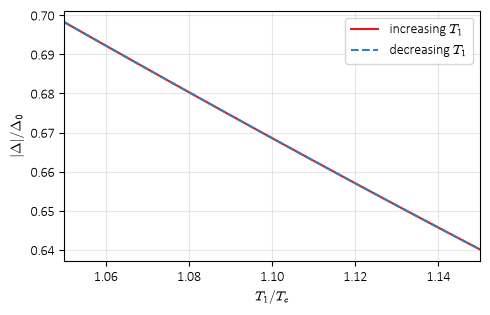

In [53]:
h = 0.65
fig, ax = plt.subplots(figsize=(5, h * 5))

ax.plot(
    xa,
    np.where(of, zf, np.nan),
    color=set1_list[0],
    label=r"increasing $T_1$",
)

ax.plot(
    xa,
    np.where(orx, zr, np.nan),
    color=set1_list[1],
    linestyle="--",
    label=r"decreasing $T_1$",
)

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$|\Delta|/\Delta_0$")

ax.set_xlim(xa[0], xa[-1])

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

In [54]:
x0 = 1.09
t1 = x0 * tc

bs = (
    ej.gam_db(
        t1,
        kap=(kaa, kab, kbb),
        wc=wc,
        mu=mu_b,
        name="bath 1",
    ),
    ej.gam_db(
        t2,
        kap=(kaa, kab, kbb),
        wc=wc,
        mu=mu_b,
        name="bath 2",
    ),
)

dsa = d0 * np.array(
    [
        0.001,
        0.002,
        0.2,
        0.5,
        1.0,
    ]
)

za = []

for di in tqdm(
    dsa,
    desc="Initial gap test",
):
    sx = ej.solve_open(
        bd,
        p,
        se2.n.copy(),
        bs,
        d=di,
        m=se2.m,
        dt=0.2,
        td=0.8,
        tm=0.8,
        tol=3.0e-6,
        nmax=100000,
        chk=50,
        prog=False,
        mode="block",
        block=512,
    )

    za.append(
        (
            di / d0,
            abs(sx.d) / d0,
            sx.err,
            sx.it,
            sx.ok,
        )
    )

for z in za:
    print(z)

Initial gap test: 100%|██████████| 5/5 [00:00<00:00, 20.45it/s]

(np.float64(0.001), 0.6743918304613775, 2.2649765014648438e-06, 400, True)
(np.float64(0.002), 0.6743970981549612, 1.1920928955078125e-06, 400, True)
(np.float64(0.2), 0.674418733325037, 2.0265579223632812e-06, 450, True)
(np.float64(0.5), 0.6744132147889017, 1.0728836059570312e-06, 500, True)
(np.float64(1.0), 0.6744159113463315, 1.7881393432617188e-06, 500, True)


Nesimetrične fore...

In [55]:
nt = 50

tn = np.linspace(0.03, 1.5, nt)

t1a = tn * tc
t2a = tn * tc

wc = np.inf

kaa = 0.1
kab = 0.2
kbb = 0.1

ds = 0.1 * d0

In [56]:
da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)

it = np.zeros(
    (nt, nt),
    dtype=int,
)

ok = np.zeros(
    (nt, nt),
    dtype=bool,
)

In [57]:
def solve_pt(i, j, n, d, m):
    t1 = t1a[i]
    t2 = t2a[j]

    bs = (
        ej.gam_db(
            t1,
            kap=(kaa, kab, kbb),
            wc=wc,
            mu=1.4,
            name="bath 1",
        ),
        ej.gam_db(
            t2,
            kap=(kaa, kab, kbb),
            wc=wc,
            mu=1.4,
            name="bath 2",
        ),
    )

    return ej.solve_open(
        bd,
        p,
        n,
        bs,
        d=d,
        m=m,
        dt=0.8,
        td=0.3,
        tm=0.3,
        tol=1.0e-5,
        nmax=20000,
        chk=20,
        prog=False,
        mode="block",
        block=512,
    )


def save_pt(i, j, so):
    da[j, i] = abs(so.d)
    ma[j, i] = so.m
    er[j, i] = so.err
    it[j, i] = so.it
    ok[j, i] = so.ok

In [58]:
for j in tqdm(
    range(nt),
    desc="T2 rows",
):
    se = sea[j]

    n0 = se.n.copy()
    d0j = max(abs(se.d), ds)
    m0 = se.m

    so0 = solve_pt(
        j,
        j,
        n0,
        d0j,
        m0,
    )

    save_pt(j, j, so0)

    n = so0.n.copy()
    d = max(abs(so0.d), ds)
    m = so0.m

    for i in tqdm(
        range(j + 1, nt),
        desc="Increasing T1",
        leave=False,
    ):
        so = solve_pt(
            i,
            j,
            n,
            d,
            m,
        )

        save_pt(i, j, so)

        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

    n = so0.n.copy()
    d = max(abs(so0.d), ds)
    m = so0.m

    for i in tqdm(
        range(j - 1, -1, -1),
        desc="Decreasing T1",
        leave=False,
    ):
        so = solve_pt(
            i,
            j,
            n,
            d,
            m,
        )

        save_pt(i, j, so)

        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

T2 rows:   0%|          | 0/50 [00:00<?, ?it/s]


AttributeError: 'NoneType' object has no attribute 'n'

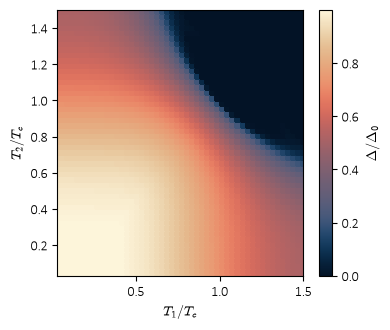

Converged: 2500 / 2500
Largest residual: 9.99713665805757e-06
Largest iteration count: 4500


In [ ]:
z = da / d0

h = 0.85
fig, ax = plt.subplots(figsize=(4, h * 4))

im = ax.pcolormesh(
    tn,
    tn,
    z,
    shading="auto",
    cmap=cmaps.lipari,
    vmin=0.0,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\Delta/\Delta_0$", rotation=90, labelpad=5)

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$T_2/T_c$")
ax.set_xlim(tn.min(), tn.max())
ax.set_ylim(tn.min(), tn.max())

plt.tight_layout()
# plt.savefig("EI_V=3_G=2_tb2d_prodbath_gapcmap_jax.pdf")
plt.show()

print("Converged:", np.count_nonzero(ok), "/", ok.size)
print("Largest residual:", np.nanmax(er))
print("Largest iteration count:", np.max(it))

In [120]:
nk = 101

bd = eu.tb_2d(
    nk=nk,
    gap=1.0,
    ta=1.0,
    tb=-0.3,
)

p = eu.MFPars(
    v=5.0,
    n=1.0,
    uh=None,
)

s0 = eu.solve_eq(
    bd,
    p,
    t=0.0,
    d=1.0,
    m=0.0,
    mix=(0.15, 0.15),
    tol=1.0e-10,
    nmax=20000,
    chk=20,
    prog=True,
)

tc = eu.critical_temperature(
    bd,
    p,
    tlo=1.0e-4,
    thi=2.0,
    tol=1.0e-7,
    nmax=100,
    prog=True,
)

d0 = abs(s0.d)

xa = np.array(
    [
        [0.9, 0.9],
        [0.01, 4],
    ]
)

kap = 0.3
out = []

for x1, x2 in tqdm(xa, desc="Temperature pairs"):
    t1 = x1 * tc
    t2 = x2 * tc
    ta = 0.5 * (t1 + t2)

    se = eu.solve_eq(
        bd,
        p,
        t=ta,
        d=max(d0, 1.0e-2),
        m=s0.m,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    bs = (
        ej.gam_db(
            t=t1,
            kap=kap,
            wc=np.inf,
            orb=None,
            mu=0.0,
            rate=ej.rate_db,
            name="bath 1",
        ),
        ej.gam_db(
            t=t2,
            kap=kap,
            wc=np.inf,
            orb=None,
            mu=0.0,
            rate=ej.rate_db,
            name="bath 2",
        ),
    )

    so = ej.solve_open(
        bd,
        p,
        se.n.copy(),
        bs,
        d=max(abs(se.d), 1.0e-2 * d0),
        m=se.m,
        dt=0.8,
        td=0.3,
        tm=0.3,
        tol=1.0e-5,
        nmax=20000,
        chk=20,
        prog=False,
        mode="pair",
    )

    out.append(so)

ka = np.linspace(
    -np.pi,
    np.pi,
    nk,
    endpoint=False,
)

kx, ky = np.meshgrid(
    ka,
    ka,
    indexing="ij",
)

za = np.asarray(out[0].n[1]).reshape(nk, nk)
zb = np.asarray(out[1].n[1]).reshape(nk, nk)

v0 = min(za.min(), zb.min())
v1 = max(za.max(), zb.max())

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

Temperature pairs: 100%|██████████| 2/2 [00:07<00:00,  3.82s/it]


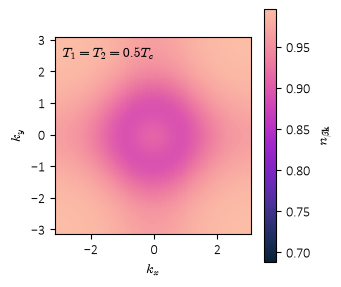

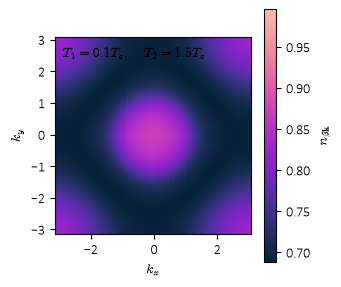

In [121]:
h = 0.9
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

im = ax.pcolormesh(
    kx,
    ky,
    za,
    shading="auto",
    cmap=cmaps.bubblegum,
    vmin=v0,
    vmax=v1,
)

im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    r"$n_{\beta\mathbf{k}}$",
    rotation=90,
    labelpad=5,
)

ax.text(
    0.04,
    0.95,
    r"$T_1=T_2=0.5T_c$",
    transform=ax.transAxes,
    ha="left",
    va="top",
)

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_xlim(ka[0], ka[-1])
ax.set_ylim(ka[0], ka[-1])
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

h = 0.9
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

im = ax.pcolormesh(
    kx,
    ky,
    zb,
    shading="auto",
    cmap=cmaps.bubblegum,
    vmin=v0,
    vmax=v1,
)

im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    r"$n_{\beta\mathbf{k}}$",
    rotation=90,
    labelpad=5,
)

ax.text(
    0.04,
    0.95,
    r"$T_1=0.1T_c,\quad T_2=1.5T_c$",
    transform=ax.transAxes,
    ha="left",
    va="top",
)

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_xlim(ka[0], ka[-1])
ax.set_ylim(ka[0], ka[-1])
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

testiranje lastnosti sistema

In [163]:
nk = 101

gap = 1.0
ta = 1.0
tb = -1.0

bd = eu.tb_2d(
    nk=nk,
    gap=gap,
    ta=ta,
    tb=tb,
)

p = eu.MFPars(
    v=5.0,
    n=1.0,
    uh=None,
)

s0 = eu.solve_eq(
    bd,
    p,
    t=0.0,
    d=1.0,
    m=0.0,
    mix=(0.15, 0.15),
    tol=1.0e-10,
    nmax=20000,
    chk=20,
    prog=True,
)

tc = eu.critical_temperature(
    bd,
    p,
    tlo=1.0e-4,
    thi=2.0,
    tol=1.0e-7,
    nmax=100,
    prog=True,
)

d0 = abs(s0.d)

t1 = 0.01 * tc
t2 = 1.1 * tc
tm = 0.5 * (t1 + t2)

se = eu.solve_eq(
    bd,
    p,
    t=tm,
    d=max(d0, 1.0e-3),
    m=s0.m,
    mix=(0.15, 0.15),
    tol=1.0e-9,
    nmax=20000,
    chk=20,
    prog=True,
)

kap = 0.3

bs = (
    ej.gam_db(
        t=t1,
        kap=kap,
        wc=np.inf,
        orb=None,
        mu=0.0,
        rate=ej.rate_db,
        name="bath 1",
    ),
    ej.gam_db(
        t=t2,
        kap=kap,
        wc=np.inf,
        orb=None,
        mu=0.0,
        rate=ej.rate_db,
        name="bath 2",
    ),
)

so = ej.solve_open(
    bd,
    p,
    se.n.copy(),
    bs,
    d=max(abs(se.d), 0.02 * d0),
    m=se.m,
    dt=0.8,
    td=0.3,
    tm=0.3,
    tol=1.0e-5,
    nmax=30000,
    chk=20,
    prog=True,
    mode="block",
    block=512,
)

print("ok =", so.ok)
print("err =", so.err)
print("Delta / Delta_0 =", abs(so.d) / d0)
print("m =", so.m)
print("mu_eq=", s0.mu)

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

Open EI JAX:   0%|          | 0/1500 [00:00<?, ?it/s]

ok = True
err = 6.377696990966797e-06
Delta / Delta_0 = 0.46701549321764974
m = -0.5050424337387085
mu_eq= 4.182559879239544


In [164]:
ns = 150
q = np.linspace(0.0, 1.0, ns, endpoint=False)

p1 = np.column_stack(
    (
        np.pi * q,
        np.zeros_like(q),
    )
)

p2 = np.column_stack(
    (
        np.full_like(q, np.pi),
        np.pi * q,
    )
)

p3 = np.column_stack(
    (
        np.pi * (1.0 - q),
        np.pi * (1.0 - q),
    )
)

kp = np.vstack(
    (
        p1,
        p2,
        p3,
        np.array([[0.0, 0.0]]),
    )
)

kx = kp[:, 0]
ky = kp[:, 1]

dx = np.diff(kp, axis=0)
ds = np.sqrt(np.sum(dx * dx, axis=1))

xp = np.concatenate(
    (
        np.array([0.0]),
        np.cumsum(ds),
    )
)

ix = np.array(
    [
        0,
        ns,
        2 * ns,
        3 * ns,
    ]
)

xt = xp[ix]

In [165]:
z = -2.0 * (np.cos(kx) + np.cos(ky))

ea = 0.5 * gap + ta * z
eb = -0.5 * gap + tb * z

ph = float(p.h)

na = 0.5 * (p.n + so.m)
nb = 0.5 * (p.n - so.m)

ha = ea + ph * nb
hb = eb + ph * na

av = 0.5 * (ha + hb)
xi = 0.5 * (ha - hb)

ek = np.sqrt(xi * xi + float(so.d) ** 2)

al = av + ek
be = av - ek

In [166]:
s00 = eu.solve_eq(
    bd,
    p,
    t=t2,
    d=1.0,
    m=0.0,
    mix=(0.15, 0.15),
    tol=1.0e-10,
    nmax=20000,
    chk=20,
    prog=True,
)
mu00= s00.mu
mu00

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

2.500000000000063

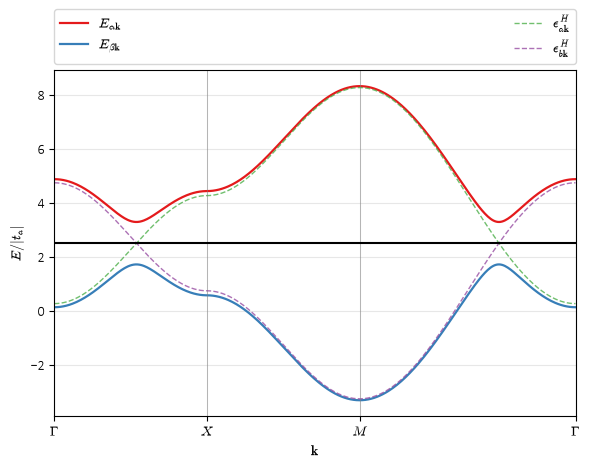

In [167]:
es = abs(ta)

h = 0.8
fig, ax = plt.subplots(figsize=(6, h * 6))

ax.plot(
    xp,
    al / es,
    color=set1_list[0],
    lw=1.6,
    label=r"$E_{\alpha\mathbf{k}}$",
)

ax.plot(
    xp,
    be / es,
    color=set1_list[1],
    lw=1.6,
    label=r"$E_{\beta\mathbf{k}}$",
)

ax.plot(
    xp,
    ha / es,
    color=set1_list[2],
    lw=1.0,
    ls="--",
    alpha=0.8,
    label=r"$\epsilon^H_{a\mathbf{k}}$",
)

ax.plot(
    xp,
    hb / es,
    color=set1_list[3],
    lw=1.0,
    ls="--",
    alpha=0.8,
    label=r"$\epsilon^H_{b\mathbf{k}}$",
)

ax.axvline(
    xt[1],
    color="0.5",
    lw=0.7,
    alpha=0.5,
)

ax.axvline(
    xt[2],
    color="0.5",
    lw=0.7,
    alpha=0.5,
)


ax.set_xticks(
    xt,
    [
        r"$\Gamma$",
        r"$X$",
        r"$M$",
        r"$\Gamma$",
    ],
)

plt.axhline(mu00, xp[0], xp[-1], color="k")
ax.set_xlabel(r"$\mathbf{k}$")
ax.set_ylabel(r"$E/|t_a|$")

ax.set_xlim(xp[0], xp[-1])
ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=2,
)

plt.tight_layout()
plt.show()

In [168]:
from scipy.interpolate import RegularGridInterpolator

ka = np.linspace(
    -np.pi,
    np.pi,
    nk,
    endpoint=False,
)

ke = np.concatenate(
    (
        ka,
        np.array([np.pi]),
    )
)

n0 = np.asarray(so.n[0]).reshape(nk, nk)
n1 = np.asarray(so.n[1]).reshape(nk, nk)


def per_int(z):
    ze = np.pad(
        z,
        ((0, 1), (0, 1)),
        mode="wrap",
    )

    fn = RegularGridInterpolator(
        (ke, ke),
        ze,
        method="linear",
        bounds_error=False,
    )

    return fn(kp)


nal = per_int(n0)
nbe = per_int(n1)

ct = np.clip(
    xi / np.maximum(ek, 1.0e-14),
    -1.0,
    1.0,
)

up = np.sqrt(0.5 * (1.0 + ct))

vp = np.copysign(
    np.sqrt(0.5 * (1.0 - ct)),
    float(so.d),
)

xl = [
    r"$\Gamma$",
    r"$X$",
    r"$M$",
    r"$\Gamma$",
]

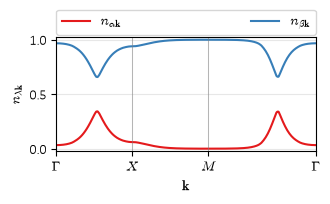

In [169]:
h = 0.62
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(
    xp,
    nal,
    color=set1_list[0],
    lw=1.5,
    label=r"$n_{\alpha\mathbf{k}}$",
)

ax.plot(
    xp,
    nbe,
    color=set1_list[1],
    lw=1.5,
    label=r"$n_{\beta\mathbf{k}}$",
)

ax.axvline(
    xt[1],
    color="0.5",
    lw=0.7,
    alpha=0.5,
)

ax.axvline(
    xt[2],
    color="0.5",
    lw=0.7,
    alpha=0.5,
)

ax.set_xticks(xt, xl)
ax.set_xlabel(r"$\mathbf{k}$")
ax.set_ylabel(r"$n_{\lambda\mathbf{k}}$")

ax.set_xlim(xp[0], xp[-1])
ax.set_ylim(-0.02, 1.02)

ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=2,
)

plt.tight_layout()
plt.show()

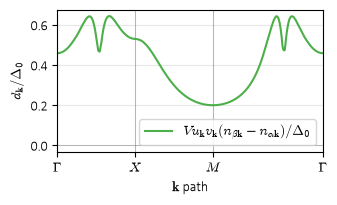

In [170]:
dg = float(p.v) * up * vp * (nbe - nal)

h = 0.62
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(
    xp,
    dg / d0,
    color=set1_list[2],
    lw=1.5,
    label=r"$V u_{\mathbf{k}}v_{\mathbf{k}} (n_{\beta \mathbf{k}}-n_{\alpha\mathbf{k}})/\Delta_0$",
)

ax.axhline(
    0.0,
    color="0.5",
    lw=0.7,
    alpha=0.5,
)

ax.axvline(
    xt[1],
    color="0.5",
    lw=0.7,
    alpha=0.5,
)

ax.axvline(
    xt[2],
    color="0.5",
    lw=0.7,
    alpha=0.5,
)

ax.set_xticks(xt, xl)
ax.set_xlabel(r"$\mathbf{k}$ path")
ax.set_ylabel(r"$d_{\mathbf{k}}/\Delta_0$")

ax.set_xlim(xp[0], xp[-1])
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

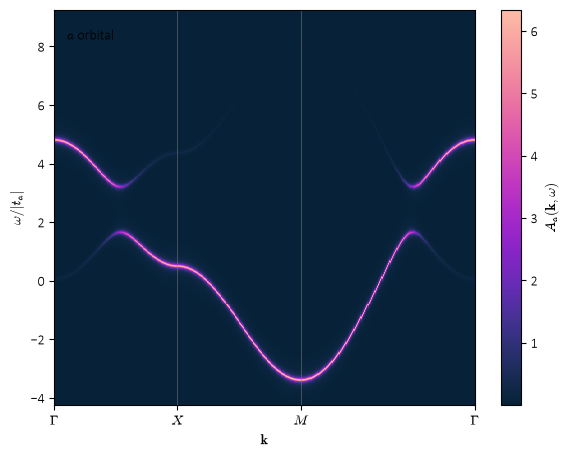

In [171]:
es = abs(ta)
bw = max(al.max(), be.max()) - min(al.min(), be.min())

om = np.linspace(
    min(al.min(), be.min()) - 0.08 * bw,
    max(al.max(), be.max()) + 0.08 * bw,
    400,
)

eta = 0.05 * es


def lor(z, eta):
    return eta / (np.pi * (z * z + eta * eta))


aa = up[None, :] ** 2 * lor(
    om[:, None] - al[None, :],
    eta,
) + vp[None, :] ** 2 * lor(
    om[:, None] - be[None, :],
    eta,
)

ab = vp[None, :] ** 2 * lor(
    om[:, None] - al[None, :],
    eta,
) + up[None, :] ** 2 * lor(
    om[:, None] - be[None, :],
    eta,
)

h = 0.78
fig, ax = plt.subplots(figsize=(6, h * 6))

im = ax.pcolormesh(
    xp,
    om / es,
    ab,
    shading="auto",
    cmap=cmaps.bubblegum,
)

im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    r"$A_a(\mathbf{k},\omega)$",
    rotation=90,
    labelpad=5,
)

ax.axvline(
    xt[1],
    color="0.5",
    lw=0.7,
    alpha=0.5,
)

ax.axvline(
    xt[2],
    color="0.5",
    lw=0.7,
    alpha=0.5,
)

ax.set_xticks(xt, xl)
ax.set_xlabel(r"$\mathbf{k}$")
ax.set_ylabel(r"$\omega/|t_a|$")

ax.set_xlim(xp[0], xp[-1])
ax.set_ylim(om[0] / es, om[-1] / es)

ax.text(
    0.03,
    0.95,
    r"$a$ orbital",
    transform=ax.transAxes,
    ha="left",
    va="top",
)

plt.tight_layout()
plt.show()

In [172]:
st = ej.mf_state(
    bd,
    p,
    d=so.d,
    m=so.m,
)

i1 = ej.total_current(
    bd,
    st,
    so.n,
    (bs[0],),
    mode="block",
    block=512,
)

i2 = ej.total_current(
    bd,
    st,
    so.n,
    (bs[1],),
    mode="block",
    block=512,
)

i1 = np.asarray(i1)
i2 = np.asarray(i2)

ee = np.asarray(st.e)
ww = np.asarray(bd.w)[None, :]

j1 = np.sum(ww * ee * i1)
j2 = np.sum(ww * ee * i2)
js = j1 + j2

print("J1 =", j1)
print("J2 =", j2)
print("J1 + J2 =", js)

J1 = -0.012013355247819725
J2 = 0.012014471654365994
J1 + J2 = 1.11640654626953e-06


Mu(T)

In [173]:
from scipy.special import expit
from scipy.optimize import minimize_scalar
nt = 40

xn = np.linspace(
    0.03,
    2.0,
    nt,
)

tt = xn * tc

meq = np.full(nt, np.nan)
m2b = np.full(nt, np.nan)

deq = np.full(nt, np.nan)
d2b = np.full(nt, np.nan)

meqa = np.full(nt, np.nan)
m2ba = np.full(nt, np.nan)

fer = np.full(nt, np.nan)
ser = np.full(nt, np.nan)
sok = np.zeros(nt, dtype=bool)


def fit_mu(e, n, w, t):
    sc = max(float(t), 1.0e-6)

    lo = float(np.min(e) - 20.0 * sc - 5.0)
    hi = float(np.max(e) + 20.0 * sc + 5.0)

    def fun(mu):
        nf = expit((mu - e) / sc)
        df = n - nf

        return np.sum(
            w[None, :]
            * df
            * df
        )

    out = minimize_scalar(
        fun,
        bounds=(lo, hi),
        method="bounded",
        options={
            "xatol": 1.0e-10,
        },
    )

    return float(out.x)


kap = 0.3

d = s0.d
m = s0.m

for q, t in enumerate(
    tqdm(tt, desc="Equilibrium and two-bath sweep")
):
    se = eu.solve_eq(
        bd,
        p,
        t=t,
        d=max(abs(d), 1.0e-7),
        m=m,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    d = se.d
    m = se.m

    bs = (
        ej.gam_db(
            t=t,
            kap=kap,
            wc=np.inf,
            orb=None,
            mu=0.0,
            rate=ej.rate_db,
            name="bath 1",
        ),
        ej.gam_db(
            t=t,
            kap=kap,
            wc=np.inf,
            orb=None,
            mu=0.0,
            rate=ej.rate_db,
            name="bath 2",
        ),
    )

    so = ej.solve_open(
        bd,
        p,
        se.n.copy(),
        bs,
        d=se.d,
        m=se.m,
        dt=0.8,
        td=0.3,
        tm=0.3,
        tol=1.0e-6,
        nmax=10000,
        chk=20,
        prog=False,
        mode="block",
        block=512,
    )

    st = ej.mf_state(
        bd,
        p,
        d=so.d,
        m=so.m,
    )

    e = np.asarray(st.e)
    n = np.asarray(so.n)
    w = np.asarray(bd.w)

    mu = fit_mu(
        e,
        n,
        w,
        t,
    )

    nf = expit(
        (mu - e)
        / max(float(t), 1.0e-6)
    )

    meq[q] = se.mu
    m2b[q] = mu

    deq[q] = abs(se.d)
    d2b[q] = abs(so.d)

    meqa[q] = se.m
    m2ba[q] = so.m

    fer[q] = np.max(
        np.abs(n - nf)
    )

    ser[q] = so.err
    sok[q] = so.ok

Equilibrium and two-bath sweep: 100%|██████████| 40/40 [01:00<00:00,  1.50s/it]


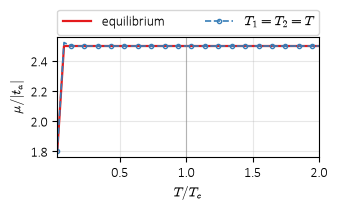

In [174]:
es = abs(ta)

h = 0.64
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412)
)

ax.plot(
    xn,
    meq / es,
    color=set1_list[0],
    lw=1.6,
    label=r"equilibrium",
)

ax.plot(
    xn,
    m2b / es,
    color=set1_list[1],
    lw=1.2,
    ls="--",
    marker="o",
    ms=3.0,
    mfc="none",
    markevery=2,
    label=r"$T_1=T_2=T$",
)

ax.axvline(
    1.0,
    color="0.5",
    lw=0.8,
    alpha=0.5,
)

ax.set_xlabel(r"$T/T_c$")
ax.set_ylabel(r"$\mu/|t_a|$")

ax.set_xlim(xn[0], xn[-1])
ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=2,
)

plt.tight_layout()
plt.show()

In [175]:
t4 = np.array([
    0.15,
    0.60,
    1.05,
    1.65,
])

k0 = 0.9* np.pi

kk = np.linspace(
    -k0,
    k0,
    151,
)

a4 = []
b4 = []
u4 = []

d = s0.d
m = s0.m

for x in tqdm(
    t4,
    desc="Selected equilibrium dispersions",
):
    se = eu.solve_eq(
        bd,
        p,
        t=x * tc,
        d=max(abs(d), 1.0e-7),
        m=m,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    d = se.d
    m = se.m

    z = -2.0 * (
        np.cos(kk)
        + 1.0
    )

    ea = 0.5 * gap + ta * z
    eb = -0.5 * gap + tb * z

    ph = float(p.h)

    na = 0.5 * (p.n + se.m)
    nb = 0.5 * (p.n - se.m)

    ha = ea + ph * nb
    hb = eb + ph * na

    av = 0.5 * (ha + hb)
    xi = 0.5 * (ha - hb)

    ek = np.sqrt(
        xi * xi
        + float(se.d) ** 2
    )

    a4.append(av + ek)
    b4.append(av - ek)
    u4.append(se.mu)

a4 = np.asarray(a4)
b4 = np.asarray(b4)
u4 = np.asarray(u4)

Selected equilibrium dispersions: 100%|██████████| 4/4 [00:09<00:00,  2.46s/it]


In [176]:
zg = -4.0

eag = 0.5 * gap + ta * zg
ebg = -0.5 * gap + tb * zg

ph = float(p.h)

nag = 0.5 * (p.n + meqa)
nbg = 0.5 * (p.n - meqa)

hag = eag + ph * nbg
hbg = ebg + ph * nag

avg = 0.5 * (hag + hbg)
xig = 0.5 * (hag - hbg)

ekg = np.sqrt(
    xig * xig
    + deq * deq
)

ag = avg + ekg
bg = avg - ekg

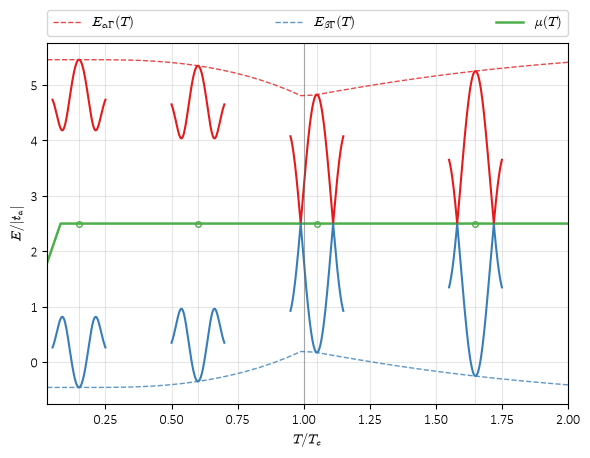

In [177]:
es = abs(ta)
dw = 0.10

h = 0.78
fig, ax = plt.subplots(
    figsize=(6, h * 6)
)

ax.plot(
    xn,
    ag / es,
    color=set1_list[0],
    lw=1.0,
    ls="--",
    alpha=0.8,
    label=r"$E_{\alpha\Gamma}(T)$",
)

ax.plot(
    xn,
    bg / es,
    color=set1_list[1],
    lw=1.0,
    ls="--",
    alpha=0.8,
    label=r"$E_{\beta\Gamma}(T)$",
)

ax.plot(
    xn,
    meq / es,
    color=set1_list[2],
    lw=1.8,
    label=r"$\mu(T)$",
)

for q in tqdm(
    range(t4.size),
    desc="Plotting dispersions",
    leave=False,
):
    xx = (
        t4[q]
        + dw * kk / k0
    )

    ax.plot(
        xx,
        a4[q] / es,
        color=set1_list[0],
        lw=1.5,
    )

    ax.plot(
        xx,
        b4[q] / es,
        color=set1_list[1],
        lw=1.5,
    )

    ax.plot(
        t4[q],
        u4[q] / es,
        marker="o",
        ms=4.0,
        mfc="none",
        mec=set1_list[2],
        color=set1_list[2],
    )

    ax.axvline(
        t4[q],
        color="0.5",
        lw=0.6,
        alpha=0.25,
    )

ax.axvline(
    1.0,
    color="0.4",
    lw=0.8,
    alpha=0.5,
)

ax.set_xlabel(r"$T/T_c$")
ax.set_ylabel(r"$E/|t_a|$")

ax.set_xlim(xn[0], xn[-1])
ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=3,
)

plt.tight_layout()
plt.show()